In [1]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
import geopandas as gpd
import matplotlib.pyplot as plt
from io import BytesIO

In [2]:
#offcial Cariboo boundary that is going to give us the exact area to work with

In [3]:
WFS_URL = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP/ows"

params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeNames": "WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP",
    "outputFormat": "application/json",
    "CQL_FILTER": "MOF_FIRE_CENTRE_NAME='Cariboo Fire Centre'"
}


# -----------------------------
response = requests.get(WFS_URL, params=params)
response.raise_for_status()


gdf = gpd.read_file(BytesIO(response.content))

print(f"Loaded {len(gdf)} fire zones")
print(gdf[["MOF_FIRE_CENTRE_NAME", "MOF_FIRE_ZONE_NAME"]])

Loaded 4 fire zones
  MOF_FIRE_CENTRE_NAME         MOF_FIRE_ZONE_NAME
0  Cariboo Fire Centre   100 Mile House Fire Zone
1  Cariboo Fire Centre        Chilcotin Fire Zone
2  Cariboo Fire Centre          Quesnel Fire Zone
3  Cariboo Fire Centre  Central Cariboo Fire Zone


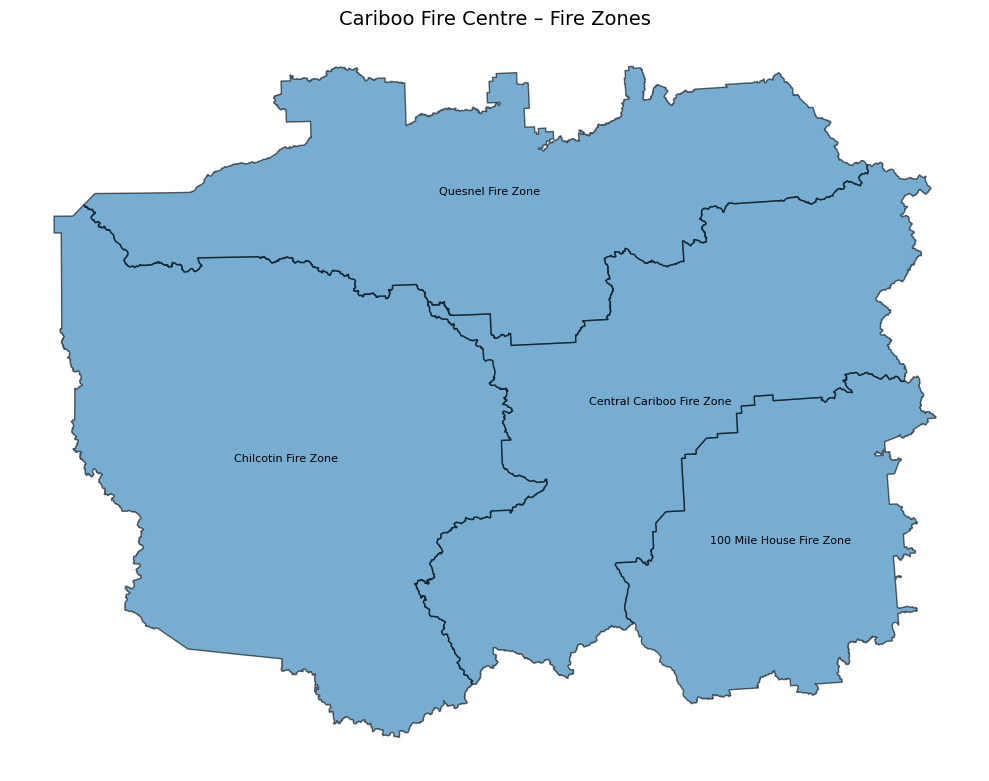

In [4]:
gdf = gdf.to_crs(epsg=3005)
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1,
    alpha=0.6
)

# Label fire zones
for idx, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row["MOF_FIRE_ZONE_NAME"],
        fontsize=8,
        ha="center"
    )

ax.set_title("Cariboo Fire Centre – Fire Zones", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [5]:
#next is the weather data extraction bounding box region that are going to be used fpr fetching the weather data through different APIs

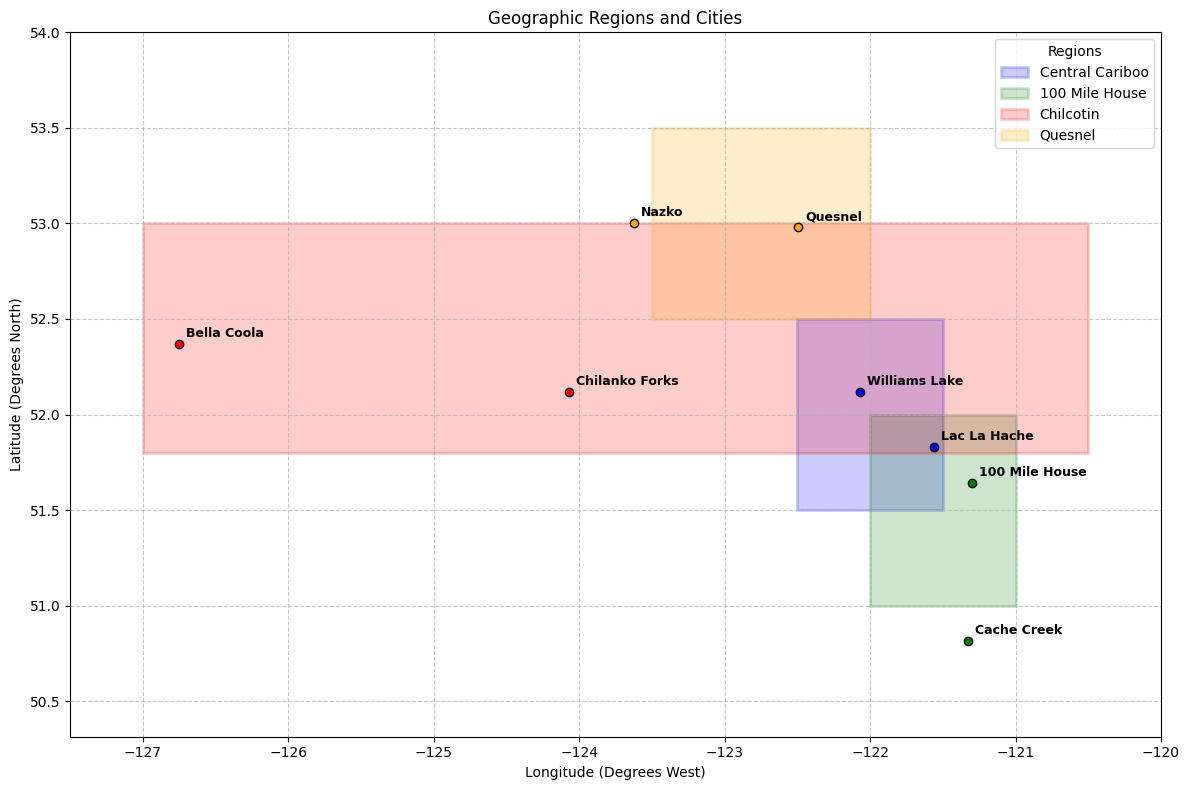

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define the regions, their boundaries, and associated cities with coordinates
regions = {
    "Central Cariboo": {
        "N": 52.5, "S": 51.5, "E": -121.5, "W": -122.5,
        "cities": {
            "Williams Lake": (52.117, -122.072),
            "Lac La Hache": (51.830, -121.560)
        },
        "color": "blue"
    },
    "100 Mile House": {
        "N": 52.0, "S": 51.0, "E": -121.0, "W": -122.0,
        "cities": {
            "100 Mile House": (51.643, -121.296),
            "Cache Creek": (50.814, -121.327)
        },
        "color": "green"
    },
    "Chilcotin": {
        "N": 53.0, "S": 51.8, "E": -120.5, "W": -127.0,
        "cities": {
            "Bella Coola": (52.370, -126.750),
            "Chilanko Forks": (52.117, -124.067)
        },
        "color": "red"
    },
    "Quesnel": {
        "N": 53.5, "S": 52.5, "E": -122.0, "W": -123.5,
        "cities": {
            "Quesnel": (52.980, -122.494),
            "Nazko": (53.000, -123.620)
        },
        "color": "orange"
    }
}

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Iterate through regions to plot rectangles and cities
for name, data in regions.items():
    # Calculate width and height for the rectangle
    width = data["E"] - data["W"]
    height = data["N"] - data["S"]
    
    # Create a rectangle patch (Anchor point is West, South)
    rect = patches.Rectangle(
        (data["W"], data["S"]), width, height,
        linewidth=2, edgecolor=data["color"], facecolor=data["color"], 
        alpha=0.2, label=name
    )
    ax.add_patch(rect)
    
    # Plot cities
    for city_name, coords in data["cities"].items():
        lat, lon = coords
        # Plot point
        ax.scatter(lon, lat, color=data["color"], zorder=5, edgecolor='black')
        # Add label
        ax.annotate(city_name, (lon, lat), 
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, weight='bold')

# Formatting the plot
ax.set_xlabel("Longitude (Degrees West)")
ax.set_ylabel("Latitude (Degrees North)")
ax.set_title("Geographic Regions and Cities")
ax.legend(loc='upper right', title="Regions")
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust axis limits to fit all elements plus a margin
all_lons = [c[1] for r in regions.values() for c in r["cities"].values()] + \
           [r["E"] for r in regions.values()] + [r["W"] for r in regions.values()]
all_lats = [c[0] for r in regions.values() for c in r["cities"].values()] + \
           [r["N"] for r in regions.values()] + [r["S"] for r in regions.values()]

ax.set_xlim(min(all_lons) - 0.5, max(all_lons) + 0.5)
ax.set_ylim(min(all_lats) - 0.5, max(all_lats) + 0.5)

# Save or show the plot
plt.tight_layout()
plt.show()

In [7]:
#now we will overlay the bounding box on the official cariboo boundary to seee how well they align

Fetching official fire zones...


C:\Users\rajpu\AppData\Local\Temp\ipykernel_45664\1293487550.py:100: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  current_handles, current_labels = ax.get_legend_handles_labels()


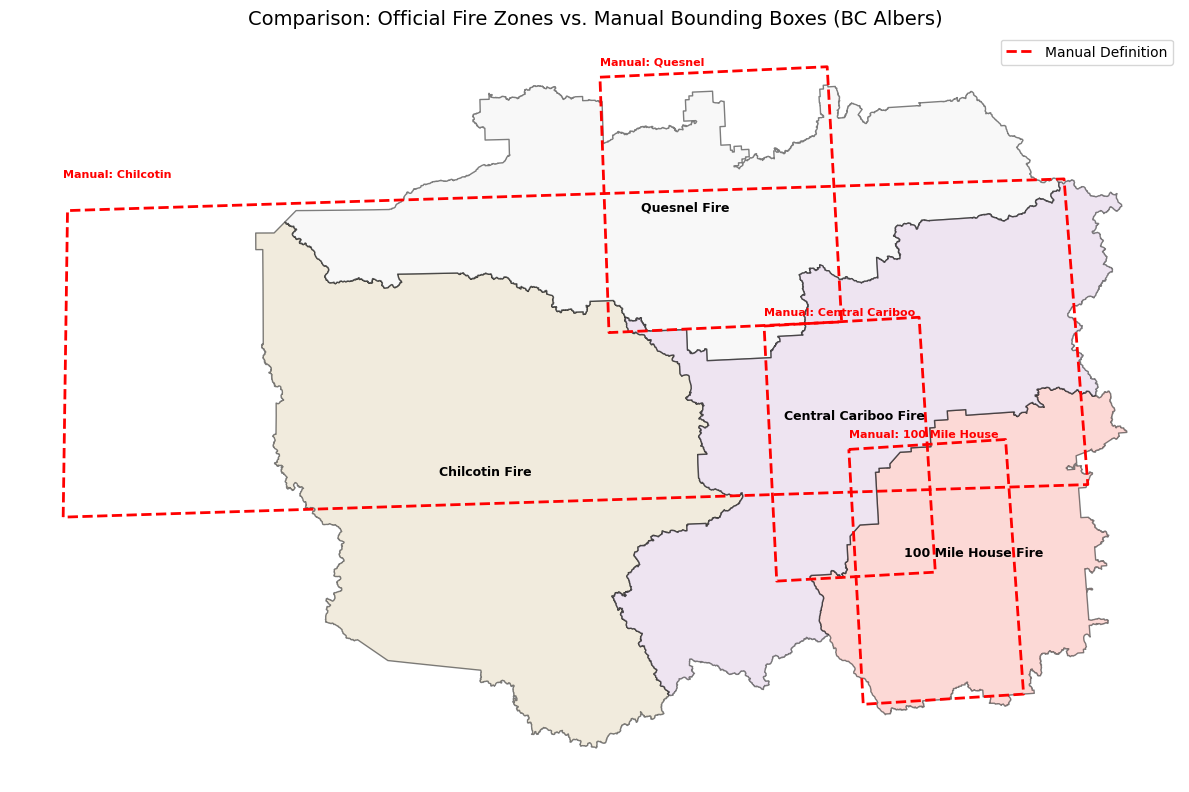

In [8]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
from io import BytesIO
from shapely.geometry import box, Point
import pandas as pd

# ---------------------------------------------------------
# 1. Fetch Official Data (WFS)
# ---------------------------------------------------------
WFS_URL = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP/ows"
params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeNames": "WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP",
    "outputFormat": "application/json",
    "CQL_FILTER": "MOF_FIRE_CENTRE_NAME='Cariboo Fire Centre'"
}

print("Fetching official fire zones...")
response = requests.get(WFS_URL, params=params)
response.raise_for_status()

# Load into GeoDataFrame and reproject to BC Albers (EPSG:3005)
official_gdf = gpd.read_file(BytesIO(response.content))
official_gdf = official_gdf.to_crs(epsg=3005)

# ---------------------------------------------------------
# 2. Define Manual Regions (Lat/Lon)
# ---------------------------------------------------------
manual_data = {
    "Region": ["Central Cariboo", "100 Mile House", "Chilcotin", "Quesnel"],
    "N": [52.5, 52.0, 53.0, 53.5],
    "S": [51.5, 51.0, 51.8, 52.5],
    "E": [-121.5, -121.0, -120.5, -122.0],
    "W": [-122.5, -122.0, -127.0, -123.5]
}

# Create geometry boxes (West, South, East, North)
geometries = [box(w, s, e, n) for w, s, e, n in zip(manual_data["W"], manual_data["S"], manual_data["E"], manual_data["N"])]

# Create GeoDataFrame in WGS84 (EPSG:4326)
manual_gdf = gpd.GeoDataFrame(manual_data, geometry=geometries, crs="EPSG:4326")

# Reproject manual regions to match the official data (EPSG:3005)
manual_gdf = manual_gdf.to_crs(official_gdf.crs)

# ---------------------------------------------------------
# 3. Plot Comparison
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 12))

# Plot A: Official Zones (Filled Polygons)
official_gdf.plot(
    ax=ax,
    column="MOF_FIRE_ZONE_NAME",
    cmap="Pastel1",
    edgecolor="black",
    linewidth=1,
    alpha=0.5,
    legend=True,
    legend_kwds={'loc': 'lower left', 'title': 'Official Zones'}
)

# Plot B: Manual Regions (Dashed Outlines)
manual_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    linestyle="--",
    label="Manual Bounding Box"
)

# ---------------------------------------------------------
# 4. Annotation
# ---------------------------------------------------------

# Label Official Zones
for idx, row in official_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["MOF_FIRE_ZONE_NAME"].replace(" Zone", ""), 
            fontsize=9, ha="center", weight="bold", color="black")

# Label Manual Boxes (offset slightly to avoid overlap)
for idx, row in manual_gdf.iterrows():
    # Get the top-left corner of the projected box for labeling
    bounds = row.geometry.bounds # (minx, miny, maxx, maxy)
    ax.text(bounds[0], bounds[3], f"Manual: {row['Region']}", 
            fontsize=8, color="red", weight="bold", ha="left", va="bottom")

# Formatting
ax.set_title("Comparison: Official Fire Zones vs. Manual Bounding Boxes (BC Albers)", fontsize=14)
ax.set_axis_off()

# Create a custom legend handle for the red dashed line
import matplotlib.lines as mlines
red_line = mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label='Manual Definition')
current_handles, current_labels = ax.get_legend_handles_labels()
# Add the red line to the existing legend logic isn't straightforward with geopandas plot, 
# so we add a secondary legend or just rely on the on-map red labels.
# Simple text annotation for legend:
ax.legend(handles=[red_line], loc='upper right')

plt.tight_layout()
plt.show()

The concept you are describing—where a mismatch between the spatial units of your target variable (official polygons) and your input features (weather bounding boxes) degrades model performance—is formally known in geospatial science as the Modifiable Areal Unit Problem (MAUP) and in machine learning as Spatial Label Noise.

The most direct and modern reference for this specific problem (spatial mismatch causing label noise in ML) is Hell & Brandmeier (2024).

This paper explicitly states that "spatial mismatch of the label and input data" introduces label noise that significantly decreases classification performance, which directly validates your "cookie cutter" solution.
Primary Reference Paper
Citation: Hell, M., & Brandmeier, M. (2024). Identifying plausible labels from noisy training data for a land use and land cover classification application in Amazônia Legal. Remote Sensing, 16(12), 2080. https://doi.org/10.3390/rs16122080

In [9]:
# code to look how much mismatch is there between the two boundary definitions

In [10]:
import geopandas as gpd



# 1. Calculate the intersection (where they agree)
intersection = gpd.overlay(manual_gdf, official_gdf, how='intersection')

# 2. Calculate areas
manual_area = manual_gdf.area.sum()
official_area = official_gdf.area.sum()
intersection_area = intersection.area.sum()

# 3. Calculate Mismatch
# How much of the Official Zone did we miss? (False Negatives)
missed_area_pct = (official_area - intersection_area) / official_area * 100

# How much extra land did we include? (Noise/False Positives)
extra_area_pct = (manual_area - intersection_area) / manual_area * 100

print(f"Missed {missed_area_pct:.2f}% of the real fire zones.")
print(f"Included {extra_area_pct:.2f}% of irrelevant land.")

Missed 14.51% of the real fire zones.
Included 17.59% of irrelevant land.


In [11]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

def filter_weather_points(weather_df, region_polygon, lat_col='latitude', lon_col='longitude'):
    """
    Filters a DataFrame of weather points, keeping only those inside the official polygon.
    
    Args:
        weather_df (pd.DataFrame): DataFrame containing weather data and coordinates.
        region_polygon (shapely.geometry.Polygon): The official government boundary.
        lat_col (str): Name of the latitude column.
        lon_col (str): Name of the longitude column.
        
    Returns:
        pd.DataFrame: A new DataFrame with only the relevant points.
    """
    # 1. Convert the raw weather data to a GeoDataFrame
    # We assume weather data usually comes in Lat/Lon (EPSG:4326)
    geometry = [Point(xy) for xy in zip(weather_df[lon_col], weather_df[lat_col])]
    weather_gdf = gpd.GeoDataFrame(weather_df, geometry=geometry, crs="EPSG:4326")

    # 2. Ensure coordinate systems match
    # We create a temporary GeoDataFrame for the polygon to handle CRS transformation easily
    poly_gdf = gpd.GeoDataFrame(index=[0], geometry=[region_polygon], crs="EPSG:3005") # Assuming input is BC Albers
    
    # Project weather points to match the Polygon's CRS (BC Albers)
    weather_gdf = weather_gdf.to_crs(poly_gdf.crs)

    # 3. The "Cookie Cutter" (Spatial Join)
    # 'predicate="within"' checks if the point is inside the polygon
    # We join the weather points with the single polygon entry
    filtered_gdf = gpd.sjoin(weather_gdf, poly_gdf, how="inner", predicate="within")

    # 4. Return the cleaned DataFrame (dropping the extra geometry columns)
    return pd.DataFrame(filtered_gdf.drop(columns=['geometry', 'index_right']))

# ==========================================
# Example Usage (Simulation)
# ==========================================

# 1. Setup: Let's grab the official "Quesnel Zone" polygon from your previous data
# (Assuming 'official_gdf' is already loaded from the previous step)
# For this demo, I will grab the first row as an example if you run this standalone:
import requests
from io import BytesIO
WFS_URL = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP/ows"
params = {"service": "WFS", "version": "2.0.0", "request": "GetFeature", 
          "typeNames": "WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP",
          "outputFormat": "application/json", "CQL_FILTER": "MOF_FIRE_CENTRE_NAME='Cariboo Fire Centre'"}
official_gdf = gpd.read_file(BytesIO(requests.get(WFS_URL, params=params).content)).to_crs(epsg=3005)

target_region = official_gdf[official_gdf['MOF_FIRE_ZONE_NAME'] == 'Quesnel Zone'].geometry.iloc[0]

# 2. Simulate "Dirty" Weather Data (A Grid based on your Bounding Box)
# Your manual Quesnel Box: N:53.5, S:52.5, W:-123.5, E:-122.0
import numpy as np
lats = np.linspace(52.5, 53.5, 20) # 20 rows
lons = np.linspace(-123.5, -122.0, 20) # 20 cols
grid_lats, grid_lons = np.meshgrid(lats, lons)
raw_weather_df = pd.DataFrame({'latitude': grid_lats.flatten(), 'longitude': grid_lons.flatten(), 'temp': np.random.randint(20, 35, 400)})

print(f"Raw Weather Points: {len(raw_weather_df)}")

# 3. APPLY THE FILTER
clean_weather_df = filter_weather_points(raw_weather_df, target_region)

print(f"Clean Weather Points: {len(clean_weather_df)}")
print(f"Removed {len(raw_weather_df) - len(clean_weather_df)} noise points ({((len(raw_weather_df) - len(clean_weather_df))/len(raw_weather_df))*100:.1f}%)")

# 4. Visualization Check
fig, ax = plt.subplots(figsize=(10, 8))
gpd.GeoSeries([target_region]).plot(ax=ax, alpha=0.3, color='orange', edgecolor='black', label='Official Region')

# Plot Dropped Points
dropped_indices = set(raw_weather_df.index) - set(clean_weather_df.index)
dropped_df = raw_weather_df.loc[list(dropped_indices)]
# We need to project these to plot them correctly over the BC Albers polygon
dropped_gdf = gpd.GeoDataFrame(dropped_df, geometry=[Point(xy) for xy in zip(dropped_df.longitude, dropped_df.latitude)], crs="EPSG:4326").to_crs(epsg=3005)
dropped_gdf.plot(ax=ax, color='red', markersize=10, label='Dropped (Noise)', marker='x')

# Plot Kept Points
kept_gdf = gpd.GeoDataFrame(clean_weather_df, geometry=[Point(xy) for xy in zip(clean_weather_df.longitude, clean_weather_df.latitude)], crs="EPSG:4326").to_crs(epsg=3005)
kept_gdf.plot(ax=ax, color='green', markersize=10, label='Kept (Valid)')

ax.set_title("The 'Cookie Cutter' Effect: Removing Weather Noise")
ax.legend()
ax.set_axis_off()
plt.show()

IndexError: single positional indexer is out-of-bounds

In [1]:
import os
from pathlib import Path

# ---- NetCDF validators ----
def is_valid_netcdf(path: Path, min_size_bytes=1024) -> tuple[bool, str]:
    """
    Returns (is_valid, reason).
    Valid if file begins with NetCDF3 magic 'CDF' or HDF5 magic (NetCDF4).
    """
    try:
        if not path.exists():
            return False, "missing"
        size = path.stat().st_size
        if size < min_size_bytes:
            return False, f"too_small({size})"

        head = path.read_bytes()[:16]

        if head.startswith(b"\x89HDF\r\n\x1a\n"):
            return True, "netcdf4_hdf5"
        if head.startswith(b"CDF"):
            return True, "netcdf3"

        # common “invalid but informative” cases
        if head.startswith(b"PK"):
            return False, "zip_file(PK)"
        if head.lstrip().lower().startswith(b"<html") or b"<!doctype html" in head.lower():
            return False, "html_error_page"
        return False, f"unknown_signature({head})"
    except Exception as e:
        return False, f"error({type(e).__name__}: {e})"


def scan_cache(cache_root: str, pattern="*.nc"):
    cache_root = Path(cache_root)

    valid = []
    invalid = []

    for fp in cache_root.rglob(pattern):
        ok, reason = is_valid_netcdf(fp)
        rec = {
            "path": str(fp),
            "size_bytes": fp.stat().st_size if fp.exists() else None,
            "reason": reason
        }
        (valid if ok else invalid).append(rec)

    valid = sorted(valid, key=lambda x: x["path"])
    invalid = sorted(invalid, key=lambda x: x["path"])
    return valid, invalid


# ---- Usage ----
# Point this at your cache root folder (the one containing zone subfolders)
CACHE_ROOT = r"C:\Users\rajpu\OneDrive\Documents\Projects_git\forest-fire-prediction\era5_cache"

valid_files, invalid_files = scan_cache(CACHE_ROOT, pattern="*.nc")

print(f"Valid:   {len(valid_files)}")
print(f"Invalid: {len(invalid_files)}")

print("\n--- INVALID FILES ---")
for x in invalid_files[:200]:  # show first 200
    print(f"{x['reason']:<25} {x['size_bytes']:>12}  {x['path']}")

print("\n--- VALID FILES (sample) ---")
for x in valid_files[:50]:  # show first 50
    print(f"{x['reason']:<12} {x['size_bytes']:>12}  {x['path']}")


Valid:   144
Invalid: 287

--- INVALID FILES ---
zip_file(PK)                     96816  C:\Users\rajpu\OneDrive\Documents\Projects_git\forest-fire-prediction\era5_cache\100_mile_house_fire_zone\era5_daily_maximum_2012_01.nc
zip_file(PK)                     95291  C:\Users\rajpu\OneDrive\Documents\Projects_git\forest-fire-prediction\era5_cache\100_mile_house_fire_zone\era5_daily_maximum_2012_02.nc
zip_file(PK)                     96261  C:\Users\rajpu\OneDrive\Documents\Projects_git\forest-fire-prediction\era5_cache\100_mile_house_fire_zone\era5_daily_maximum_2012_03.nc
zip_file(PK)                     95533  C:\Users\rajpu\OneDrive\Documents\Projects_git\forest-fire-prediction\era5_cache\100_mile_house_fire_zone\era5_daily_maximum_2012_04.nc
zip_file(PK)                     96304  C:\Users\rajpu\OneDrive\Documents\Projects_git\forest-fire-prediction\era5_cache\100_mile_house_fire_zone\era5_daily_maximum_2012_05.nc
zip_file(PK)                     95588  C:\Users\rajpu\OneDrive\Documen